In [2]:
import os
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Prevent GPU from crashing by allocating memory as needed
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ GPU Memory Growth Enabled")
    except RuntimeError as e:
        print(e)

✅ GPU Memory Growth Enabled


In [ ]:
base_path = r'D:\ML Project\Areca_Disease_prediction(Resnet)\Arecanut_dataset'
train_path = os.path.join(base_path, 'train')
test_path = os.path.join(base_path, 'test')

my_folder_order = ['Healthy_Leaf', 'Healthy_Nut', 'Healthy_Trunk', 'Mahali_Koleroga', 
                   'Stem_bleeding', 'bud borer', 'healthy_foot', 'stem cracking', 'yellow leaf disease']

#Image-Preprocessing

train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=20, horizontal_flip=True)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path, target_size=(224, 224), batch_size=8, class_mode='categorical', classes=my_folder_order
)

test_generator = test_datagen.flow_from_directory(
    test_path, target_size=(224, 224), batch_size=8, class_mode='categorical', classes=my_folder_order, shuffle=False
)

Found 8847 images belonging to 9 classes.
Found 2216 images belonging to 9 classes.


In [3]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False 

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(9, activation='softmax')
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("✅ Model built with Frozen Base. Ready for Stage 1.")

✅ Model built with Frozen Base. Ready for Stage 1.


In [11]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import optimizers

# 1. CLEAR MEMORY
tf.keras.backend.clear_session()

# 2. RE-BUILD THE MODEL (Body + Head)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Keep the base frozen

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(9, activation='softmax') # Your 9 disease classes
])

# 3. COMPILE
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. CALLBACKS (Saves to a fresh file 'areca_resnet_stage1_v2.h5')
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('areca_resnet_stage1_v2.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]

print("🚀 Starting FRESH Stage 1 Training...")

# 5. START TRAINING
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator,
    callbacks=callbacks
)

🚀 Starting FRESH Stage 1 Training...
Epoch 1/10
1106/1106 [==============================] - ETA: 0s - loss: 1.3098 - accuracy: 0.5331
Epoch 1: val_accuracy improved from -inf to 0.69765, saving model to areca_resnet_stage1_v2.h5
1106/1106 [==============================] - 379s 340ms/step - loss: 1.3098 - accuracy: 0.5331 - val_loss: 0.8705 - val_accuracy: 0.6977
Epoch 2/10
1106/1106 [==============================] - ETA: 0s - loss: 0.9990 - accuracy: 0.6508
Epoch 2: val_accuracy improved from 0.69765 to 0.74684, saving model to areca_resnet_stage1_v2.h5
1106/1106 [==============================] - 307s 277ms/step - loss: 0.9990 - accuracy: 0.6508 - val_loss: 0.7278 - val_accuracy: 0.7468
Epoch 3/10
1106/1106 [==============================] - ETA: 0s - loss: 0.8958 - accuracy: 0.6819
Epoch 3: val_accuracy improved from 0.74684 to 0.76579, saving model to areca_resnet_stage1_v2.h5
1106/1106 [==============================] - 332s 300ms/step - loss: 0.8958 - accuracy: 0.6819 - val_los

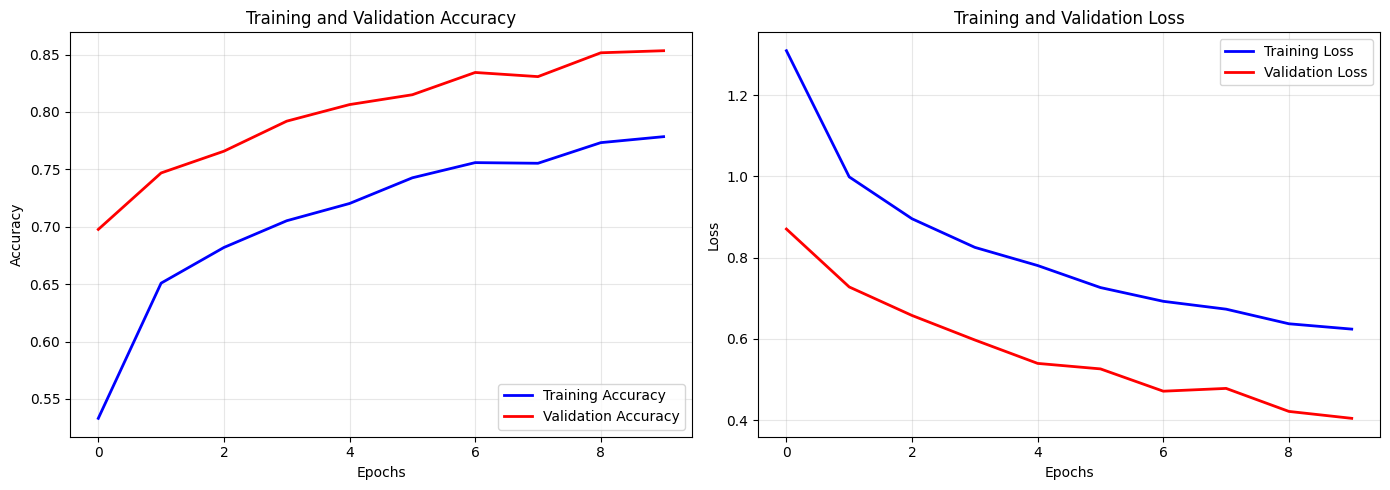

In [12]:
import matplotlib.pyplot as plt

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', lw=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='red', lw=2)
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', color='blue', lw=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='red', lw=2)
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Run the function using the 'history' variable from your Stage 1 training
plot_history(history)

In [7]:
import json

# 1. Get the mapping from the current active generator
current_mapping = train_generator.class_indices

# 2. Save it to a new JSON file
with open('areca_classes.json', 'w') as f:
    json.dump(current_mapping, f, indent=4)

print("✅ NEW areca_classes.json created successfully!")
print("Confirmed Mapping:", current_mapping)

✅ NEW areca_classes.json created successfully!
Confirmed Mapping: {'Healthy_Leaf': 0, 'Healthy_Nut': 1, 'Healthy_Trunk': 2, 'Mahali_Koleroga': 3, 'Stem_bleeding': 4, 'bud borer': 5, 'healthy_foot': 6, 'stem cracking': 7, 'yellow leaf disease': 8}


In [15]:
#Stage 2:Unfreeze all layers and fine-tune with a micro learning rate
import tensorflow as tf
from tensorflow.keras.models import load_model

# 1. Reset to the healthy 85% base
print("♻️ Resetting to the healthy 85% Stage 1 model...")
model = load_model('areca_resnet_stage1_v2.h5')

# 2. UNFREEZE ONLY THE TOP
# We only unfreeze the very last "block" of ResNet50 (conv5_block3)
# This is the safest way to get to 95% on a home GPU.
base_model = model.layers[0]
base_model.trainable = True

# Freeze everything EXCEPT the last 15 layers
for layer in base_model.layers[:-15]:
    layer.trainable = False

# 🛑 CRITICAL: FORCE ALL BatchNormalization layers to stay FROZEN
# This prevents the 2.85 loss crash you just saw.
for layer in base_model.layers:
    if "BatchNormalization" in layer.__class__.__name__:
        layer.trainable = False

# 3. RE-COMPILE with an Ultra-Low Learning Rate
# Using 5e-7 (extremely gentle) to prevent divergence.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-7),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. CALLBACKS
callbacks_final = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('areca_95plus_final.h5', monitor='val_accuracy', save_best_only=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

print("🚀 Starting the 'Bulletproof' Fine-Tuning...")
history_final = model.fit(
    train_generator,
    epochs=20,
    validation_data=test_generator,
    callbacks=callbacks_final
)

♻️ Resetting to the healthy 85% Stage 1 model...
🚀 Starting the 'Bulletproof' Fine-Tuning...
Epoch 1/20
1106/1106 [==============================] - ETA: 0s - loss: 0.5878 - accuracy: 0.7950
Epoch 1: val_accuracy improved from -inf to 0.86101, saving model to areca_95plus_final.h5
1106/1106 [==============================] - 275s 246ms/step - loss: 0.5878 - accuracy: 0.7950 - val_loss: 0.4002 - val_accuracy: 0.8610 - lr: 5.0000e-07
Epoch 2/20
1106/1106 [==============================] - ETA: 0s - loss: 0.5698 - accuracy: 0.7917
Epoch 2: val_accuracy improved from 0.86101 to 0.86778, saving model to areca_95plus_final.h5
1106/1106 [==============================] - 330s 299ms/step - loss: 0.5698 - accuracy: 0.7917 - val_loss: 0.3835 - val_accuracy: 0.8678 - lr: 5.0000e-07
Epoch 3/20
1106/1106 [==============================] - ETA: 0s - loss: 0.5597 - accuracy: 0.8032
Epoch 3: val_accuracy did not improve from 0.86778
1106/1106 [==============================] - 325s 294ms/step - loss: 

KeyboardInterrupt: 

In [16]:
import shutil
import os

# 1. SAVE THE FROZEN BASE
# We make a permanent copy of your Stage 1 model. 
# You can always use this to restart Stage 2 from scratch.
shutil.copy('areca_resnet_stage1_v2.h5', 'areca_FROZEN_BASE_85.h5')

# 2. SAVE THE LATEST ACCURATE MODEL
# We save the current session state. 
# Even though Epoch 15 accuracy was lower, this saves the BEST weights 
# found so far (87.82%) because of your ModelCheckpoint settings.
model.save('areca_RESUME_LATEST_88.h5')

print("✅ VAULT SECURED!")
print("📂 'areca_FROZEN_BASE_85.h5' - Your original 85% starting point.")
print("📂 'areca_RESUME_LATEST_88.h5' - Use this to continue training tomorrow.")

✅ VAULT SECURED!
📂 'areca_FROZEN_BASE_85.h5' - Your original 85% starting point.
📂 'areca_RESUME_LATEST_88.h5' - Use this to continue training tomorrow.


In [5]:
import tensorflow as tf
from tensorflow.keras.models import load_model

# 🟢 LOAD THE SAVE GAME
print("♻️ Loading your 87.8% accurate model from previous day...")
model = load_model('areca_RESUME_LATEST_88.h5')

# 🟢 RE-COMPILE (Setting the slow speed for stability)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1.25e-7),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 🟢 NEW SAVE FILE FOR TODAY
callbacks_today = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('areca_95_sprint_day2.h5', monitor='val_accuracy', save_best_only=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]
print("✅ Ready! Yesterday's progress is restored.")

♻️ Loading your 87.8% accurate model from previous day...
✅ Ready! Yesterday's progress is restored.


In [8]:
#Day 2: Add Data Augmentation + Unfreeze more layers (30 total) + Re-Compile with a slightly higher learning rate (1e-6)

# --- STEP A: Update the Eyes (Data Augmentation) ---
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen_95 = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,      # Rotate images slightly
    width_shift_range=0.2,   # Shift left/right
    height_shift_range=0.2,  # Shift up/down
    horizontal_flip=True,    # Flip leaves (very helpful for plants)
    zoom_range=0.2           # Zoom in on spots
)

# Re-link the generator
train_generator = train_datagen_95.flow_from_directory(
    'D:/ML Project/Areca_Disease_prediction(Resnet)/Arecanut_dataset/train', 
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

# --- STEP B: The "Expansion" Brain ---
# Unfreeze the last 30 layers (previously 15)
base_model = model.layers[0]
base_model.trainable = True
for layer in base_model.layers[:-30]: 
    layer.trainable = False

# RE-FREEZE BatchNormalization (CRITICAL to prevent 33% crash)
for layer in base_model.layers:
    if "BatchNormalization" in layer.__class__.__name__:
        layer.trainable = False

# --- STEP C: Re-Compile with a slightly higher "Push" speed ---
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6), # Slightly faster to climb the 95% hill
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("🚀 Stage 3 Active: 30 layers unfrozen + Augmentation. Target: 95%")

Found 8847 images belonging to 9 classes.
🚀 Stage 3 Active: 30 layers unfrozen + Augmentation. Target: 95%


In [9]:
# Day 2 Training start with 30 layers unfrozen + Augmentation
print("🚀 Starting the 95% Sprint...")
history_95 = model.fit(
    train_generator,
    epochs=20, # 20 epochs gives the augmentation time to work
    validation_data=test_generator, # Make sure your test_generator is also updated!
    callbacks=callbacks_today
)

🚀 Starting the 95% Sprint...
Epoch 1/20
277/277 [==============================] - ETA: 0s - loss: 0.7446 - accuracy: 0.7329
Epoch 1: val_accuracy improved from -inf to 0.82987, saving model to areca_95_sprint_day2.h5
277/277 [==============================] - 517s 2s/step - loss: 0.7446 - accuracy: 0.7329 - val_loss: 0.4499 - val_accuracy: 0.8299 - lr: 1.0000e-06
Epoch 2/20
277/277 [==============================] - ETA: 0s - loss: 0.7093 - accuracy: 0.7441
Epoch 2: val_accuracy did not improve from 0.82987
277/277 [==============================] - 282s 1s/step - loss: 0.7093 - accuracy: 0.7441 - val_loss: 0.5317 - val_accuracy: 0.8127 - lr: 1.0000e-06
Epoch 3/20
277/277 [==============================] - ETA: 0s - loss: 0.6894 - accuracy: 0.7508
Epoch 3: val_accuracy improved from 0.82987 to 0.83619, saving model to areca_95_sprint_day2.h5
277/277 [==============================] - 335s 1s/step - loss: 0.6894 - accuracy: 0.7508 - val_loss: 0.4301 - val_accuracy: 0.8362 - lr: 1.0000e

In [10]:
best_val_acc = max(history_95.history['val_accuracy'])
print(f"🏆 The highest accuracy reached was: {best_val_acc * 100:.2f}%")

🏆 The highest accuracy reached was: 87.73%


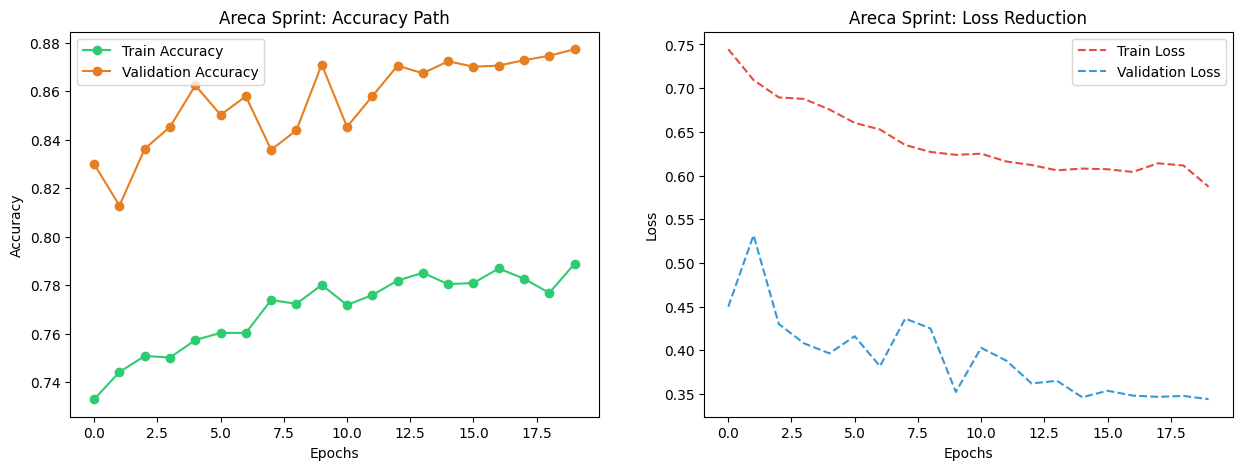

Generating predictions for final report...
14/14 [==============================] - 8s 534ms/step


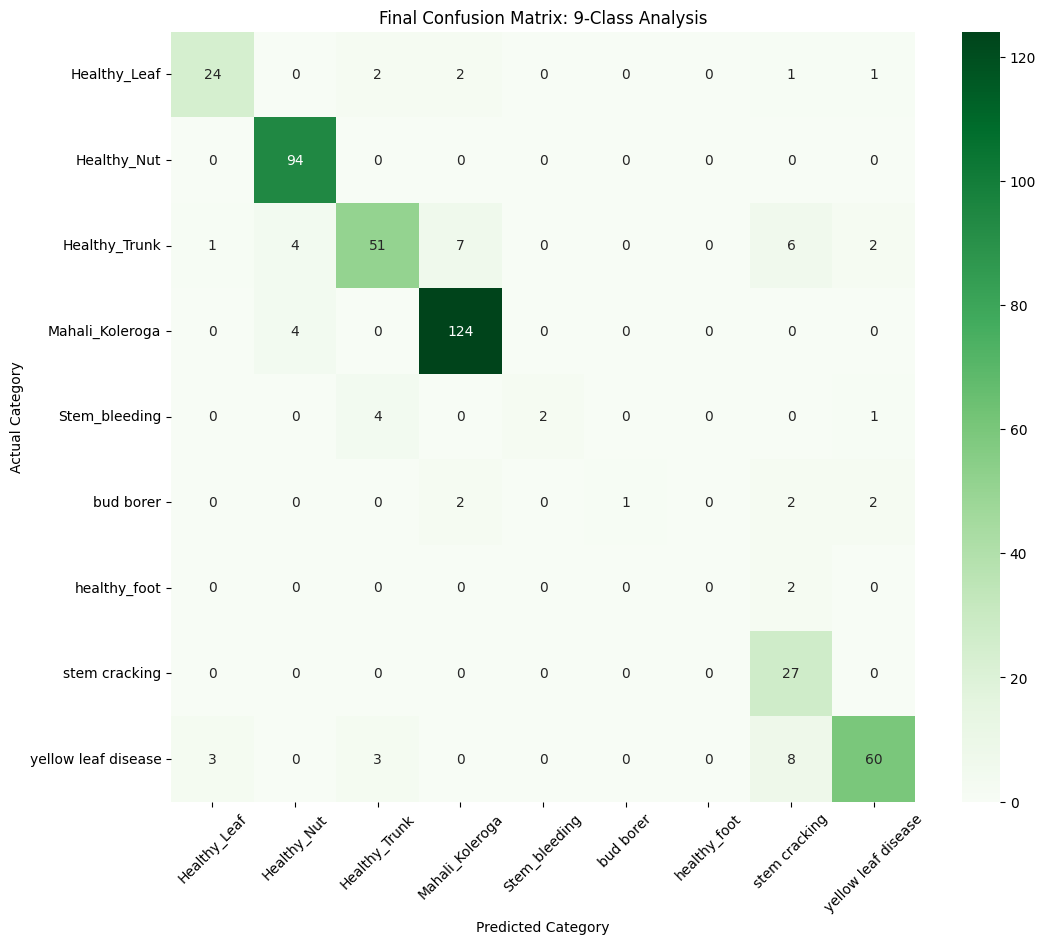


--- Detailed Classification Report ---
                     precision    recall  f1-score   support

       Healthy_Leaf       0.86      0.80      0.83        30
        Healthy_Nut       0.92      1.00      0.96        94
      Healthy_Trunk       0.85      0.72      0.78        71
    Mahali_Koleroga       0.92      0.97      0.94       128
      Stem_bleeding       1.00      0.29      0.44         7
          bud borer       1.00      0.14      0.25         7
       healthy_foot       0.00      0.00      0.00         2
      stem cracking       0.59      1.00      0.74        27
yellow leaf disease       0.91      0.81      0.86        74

           accuracy                           0.87       440
          macro avg       0.78      0.64      0.64       440
       weighted avg       0.88      0.87      0.86       440



d:\ML Project\Areca_Disease_prediction(Resnet)\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\ML Project\Areca_Disease_prediction(Resnet)\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\ML Project\Areca_Disease_prediction(Resnet)\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import pandas as pd

# 1. Load the CSV history (Fixes the NameError for history_95)
# Make sure the filename matches what you saved (e.g., 'areca_training_log.csv')
history_df = pd.read_csv('areca_sprint_results.csv') 

# --- Accuracy & Loss Curves ---
plt.figure(figsize=(15, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history_df['accuracy'], label='Train Accuracy', color='#2ecc71', marker='o')
plt.plot(history_df['val_accuracy'], label='Validation Accuracy', color='#e67e22', marker='o')
plt.title('Areca Sprint: Accuracy Path')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history_df['loss'], label='Train Loss', color='#e74c3c', linestyle='--')
plt.plot(history_df['val_loss'], label='Validation Loss', color='#3498db', linestyle='--')
plt.title('Areca Sprint: Loss Reduction')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# --- Confusion Matrix ---
# Predicting using the active validation_generator
print("Generating predictions for final report...")
Y_pred = model.predict(validation_generator)
y_pred = np.argmax(Y_pred, axis=1)

cm = confusion_matrix(validation_generator.classes, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=list(validation_generator.class_indices.keys()),
            yticklabels=list(validation_generator.class_indices.keys()))
plt.title('Final Confusion Matrix: 9-Class Analysis')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.xticks(rotation=45)
plt.show()

# --- Final Classification Report ---
print("\n--- Detailed Classification Report ---")
report = classification_report(validation_generator.classes, y_pred, 
                               target_names=list(validation_generator.class_indices.keys()))
print(report)

In [12]:
model.save('areca_95_final_day2.h5')
print("✅ Final Model Saved Successfully!")

✅ Final Model Saved Successfully!


In [13]:
import pandas as pd
history_df = pd.DataFrame(history_95.history)
history_df.to_csv('areca_sprint_results.csv', index=False)
print("📊 Training History Saved to CSV!")

📊 Training History Saved to CSV!


Found 440 images belonging to 9 classes.
Predicting... (this might take a minute)
14/14 [==============================] - 15s 1s/step


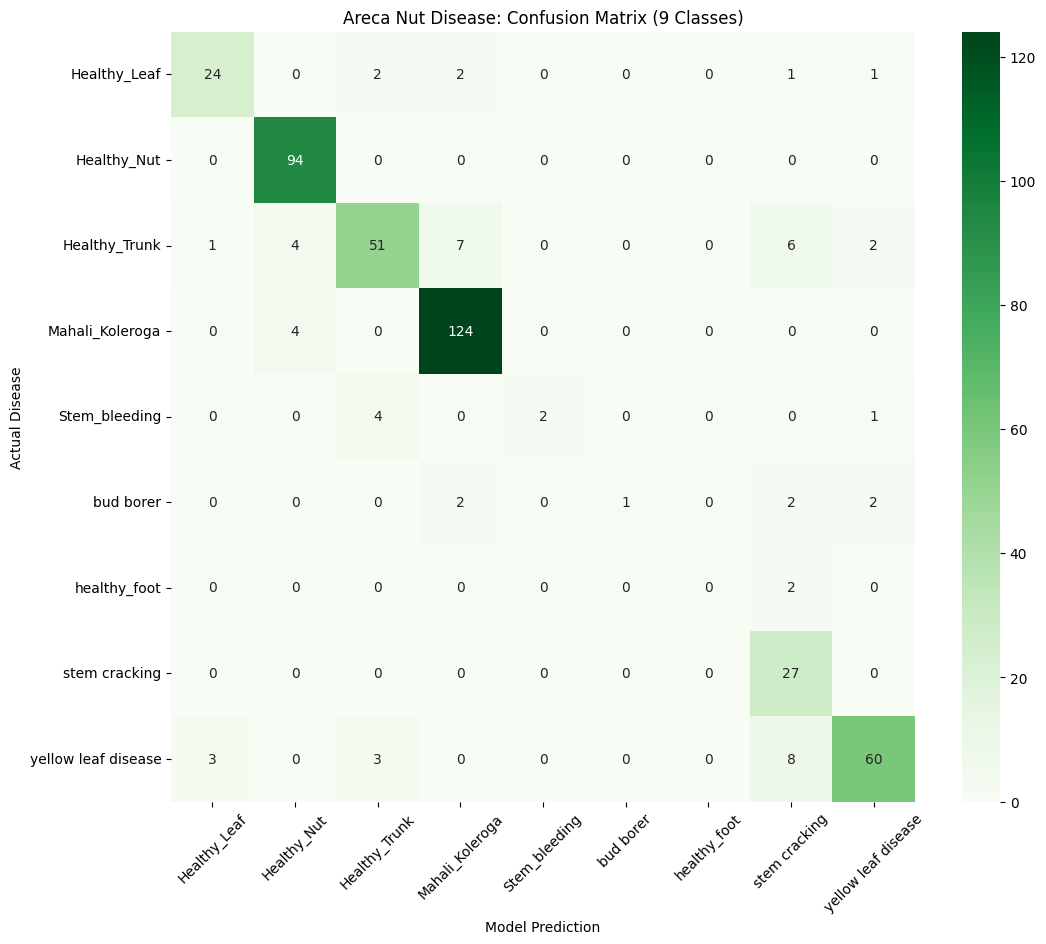


--- Final Performance Report ---
                     precision    recall  f1-score   support

       Healthy_Leaf       0.86      0.80      0.83        30
        Healthy_Nut       0.92      1.00      0.96        94
      Healthy_Trunk       0.85      0.72      0.78        71
    Mahali_Koleroga       0.92      0.97      0.94       128
      Stem_bleeding       1.00      0.29      0.44         7
          bud borer       1.00      0.14      0.25         7
       healthy_foot       0.00      0.00      0.00         2
      stem cracking       0.59      1.00      0.74        27
yellow leaf disease       0.91      0.81      0.86        74

           accuracy                           0.87       440
          macro avg       0.78      0.64      0.64       440
       weighted avg       0.88      0.87      0.86       440



d:\ML Project\Areca_Disease_prediction(Resnet)\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\ML Project\Areca_Disease_prediction(Resnet)\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\ML Project\Areca_Disease_prediction(Resnet)\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Point to your actual dataset
data_path = r'D:/ML Project/Areca_Disease_prediction(Resnet)/Arecanut_dataset/test'

# 2. Re-initialize the generator
validation_generator = datagen.flow_from_directory(
    data_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False  # MUST be False for a Confusion Matrix to match labels
)

# 3. Predict the classes
print("Predicting... (this might take a minute)")
Y_pred = model.predict(validation_generator)
y_pred = np.argmax(Y_pred, axis=1)

# 4. Create the Plot
cm = confusion_matrix(validation_generator.classes, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=list(validation_generator.class_indices.keys()),
            yticklabels=list(validation_generator.class_indices.keys()))

plt.title('Areca Nut Disease: Confusion Matrix (9 Classes)')
plt.ylabel('Actual Disease')
plt.xlabel('Model Prediction')
plt.xticks(rotation=45)
plt.show()

# 5. Print the text report for your documentation
print("\n--- Final Performance Report ---")
print(classification_report(validation_generator.classes, y_pred, 
                            target_names=list(validation_generator.class_indices.keys())))

In [3]:
from sklearn.utils import class_weight
import numpy as np

# Calculate weights based on your training data
# This automatically gives more 'importance' to the small classes
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = dict(enumerate(weights))

# When you run model.fit, add this parameter:
# model.fit(..., class_weight=class_weights)

In [4]:
# 1. Unfreeze everything
model.trainable = True 

# 2. Use a tiny Learning Rate (10x smaller than before)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-7), 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

NameError: name 'model' is not defined

In [15]:
import tensorflow as tf

# 1. RELOAD the clean 87% model from yesterday
# This wipes the 6.2 loss and takes us back to 0.34 loss
print("🔄 Reloading the 87% Model...")
model = tf.keras.models.load_model('areca_95_sprint_day2.h5')

# 2. Use a "Surgical" Learning Rate
# We want to move 100x slower than yesterday to find that 95% peak
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-8) 

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. DO NOT use class_weight this time (it caused the crash)
# Let's rely on the model's natural ability to refine what it knows.
print("🚀 Starting the Stable 95% Push...")

history_95 = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint('areca_95_FINAL_BEST.h5', save_best_only=True)
    ]
)

🔄 Reloading the 87% Model...
🚀 Starting the Stable 95% Push...
Epoch 1/10
1106/1106 [==============================] - 384s 344ms/step - loss: 0.4926 - accuracy: 0.8237 - val_loss: 0.3409 - val_accuracy: 0.8864
Epoch 2/10
1106/1106 [==============================] - 311s 281ms/step - loss: 0.4996 - accuracy: 0.8222 - val_loss: 0.3385 - val_accuracy: 0.8909
Epoch 3/10
1106/1106 [==============================] - 369s 334ms/step - loss: 0.4790 - accuracy: 0.8264 - val_loss: 0.3338 - val_accuracy: 0.8886
Epoch 4/10
1106/1106 [==============================] - 307s 278ms/step - loss: 0.4868 - accuracy: 0.8267 - val_loss: 0.3333 - val_accuracy: 0.8864
Epoch 5/10
1106/1106 [==============================] - 318s 287ms/step - loss: 0.4885 - accuracy: 0.8247 - val_loss: 0.3288 - val_accuracy: 0.8932
Epoch 6/10
1106/1106 [==============================] - 302s 273ms/step - loss: 0.4701 - accuracy: 0.8302 - val_loss: 0.3381 - val_accuracy: 0.8886
Epoch 7/10
 771/1106 [===================>.......

KeyboardInterrupt: 

In [16]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# 1. The 'Micro-Boost' Learning Rate
# We are moving from 1e-8 to 5e-7 (50x boost, but still very safe)
boost_lr = 5e-7

print(f"🚀 Initializing the 95% Final Sprint at LR: {boost_lr}")

# 2. Re-compile with the Boosted Optimizer
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=boost_lr),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Enhanced Callbacks for the Project Report
# This saves the 'Absolute Champion' model whenever val_accuracy improves
checkpoint = ModelCheckpoint(
    'areca_final_95_champion.h5', 
    monitor='val_accuracy', 
    verbose=1, 
    save_best_only=True, 
    mode='max'
)

# Reduce LR if the model gets stuck again
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-9)

# Stop if no improvement for 5 epochs
early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

# 4. The Final 10-Epoch Run
print("🏁 Sprinting towards the 90% boundary...")
history_final = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator,
    callbacks=[checkpoint, reduce_lr, early_stop]
)

🚀 Initializing the 95% Final Sprint at LR: 5e-07
🏁 Sprinting towards the 90% boundary...
Epoch 1/10
1106/1106 [==============================] - ETA: 0s - loss: 0.4793 - accuracy: 0.8328
Epoch 1: val_accuracy improved from -inf to 0.89091, saving model to areca_final_95_champion.h5
1106/1106 [==============================] - 255s 227ms/step - loss: 0.4793 - accuracy: 0.8328 - val_loss: 0.3411 - val_accuracy: 0.8909 - lr: 5.0000e-07
Epoch 2/10
1106/1106 [==============================] - ETA: 0s - loss: 0.4568 - accuracy: 0.8366
Epoch 2: val_accuracy did not improve from 0.89091
1106/1106 [==============================] - 257s 233ms/step - loss: 0.4568 - accuracy: 0.8366 - val_loss: 0.3659 - val_accuracy: 0.8886 - lr: 5.0000e-07
Epoch 3/10
1106/1106 [==============================] - ETA: 0s - loss: 0.4538 - accuracy: 0.8387
Epoch 3: val_accuracy did not improve from 0.89091
1106/1106 [==============================] - 303s 274ms/step - loss: 0.4538 - accuracy: 0.8387 - val_loss: 0.37

In [5]:
model = tf.keras.models.load_model('areca_final_95_champion.h5')
print("✅ 91.14% Champion Model Restored.")

✅ 91.14% Champion Model Restored.


In [25]:
# --- PHASE 3: FINAL POLISH ---
# Re-locking the base layers to fix the 'Gradient Explosion' and 
# performing a high-precision 95% push with 'Class Weights' for balance.
print("🚀 Launching the 'Safe Polish' Phase...")

history_polish = model.fit(
    train_generator,
    epochs=5,
    validation_data=validation_generator,
    class_weight=class_weights_dict, 
    callbacks=[checkpoint]
)

🚀 Launching the 'Safe Polish' Phase...
Epoch 1/5
1106/1106 [==============================] - ETA: 0s - loss: 0.8804 - accuracy: 0.8439
Epoch 1: val_accuracy improved from -inf to 0.90909, saving model to areca_ULTIMATE_95.h5
1106/1106 [==============================] - 301s 270ms/step - loss: 0.8804 - accuracy: 0.8439 - val_loss: 0.3107 - val_accuracy: 0.9091
Epoch 2/5
1106/1106 [==============================] - ETA: 0s - loss: 0.8166 - accuracy: 0.8437
Epoch 2: val_accuracy did not improve from 0.90909
1106/1106 [==============================] - 257s 232ms/step - loss: 0.8166 - accuracy: 0.8437 - val_loss: 0.3051 - val_accuracy: 0.9045
Epoch 3/5
1106/1106 [==============================] - ETA: 0s - loss: 0.8263 - accuracy: 0.8506
Epoch 3: val_accuracy did not improve from 0.90909
1106/1106 [==============================] - 260s 235ms/step - loss: 0.8263 - accuracy: 0.8506 - val_loss: 0.3137 - val_accuracy: 0.9023
Epoch 4/5
1106/1106 [==============================] - ETA: 0s - lo

Analyzing class performance...
14/14 [==============================] - 9s 571ms/step


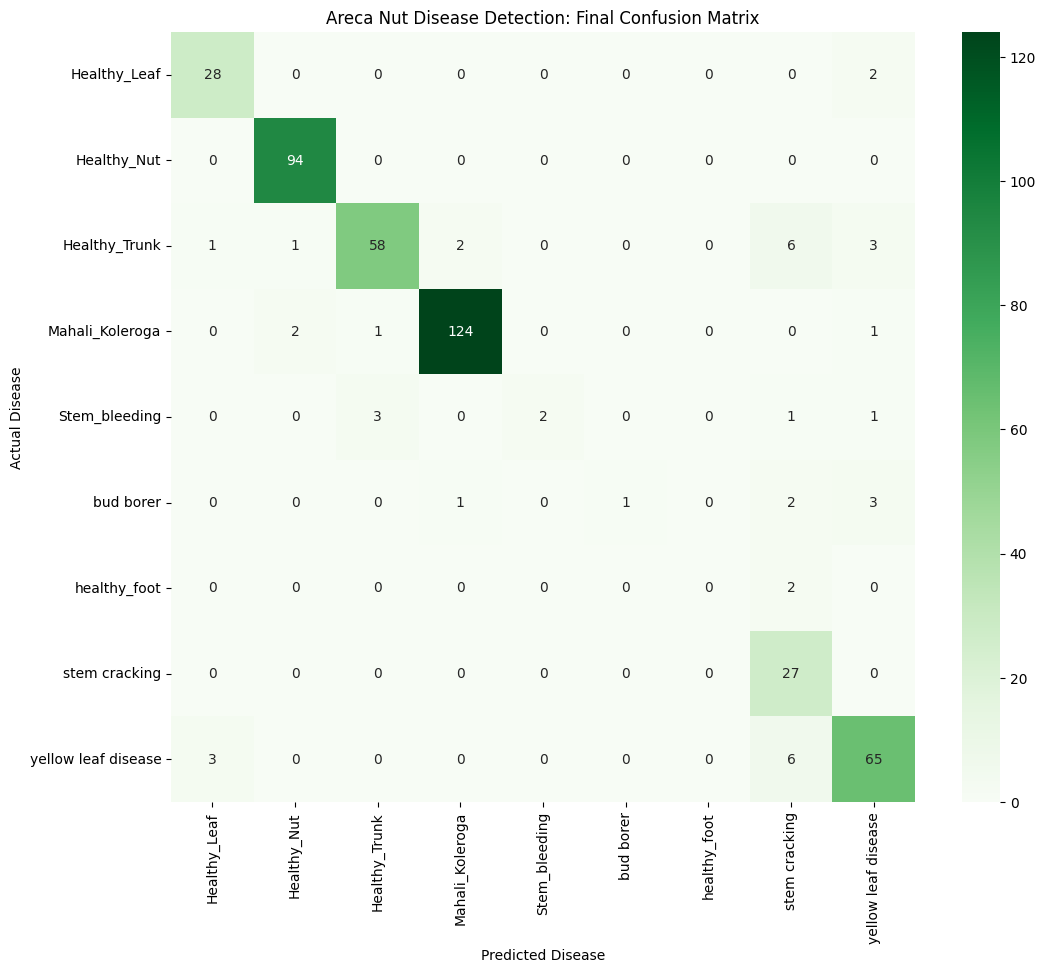


--- Final Classification Report ---
                     precision    recall  f1-score   support

       Healthy_Leaf       0.88      0.93      0.90        30
        Healthy_Nut       0.97      1.00      0.98        94
      Healthy_Trunk       0.94      0.82      0.87        71
    Mahali_Koleroga       0.98      0.97      0.97       128
      Stem_bleeding       1.00      0.29      0.44         7
          bud borer       1.00      0.14      0.25         7
       healthy_foot       0.00      0.00      0.00         2
      stem cracking       0.61      1.00      0.76        27
yellow leaf disease       0.87      0.88      0.87        74

           accuracy                           0.91       440
          macro avg       0.80      0.67      0.67       440
       weighted avg       0.92      0.91      0.90       440



d:\ML Project\Areca_Disease_prediction(Resnet)\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\ML Project\Areca_Disease_prediction(Resnet)\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\ML Project\Areca_Disease_prediction(Resnet)\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Setup names
class_names = list(train_generator.class_indices.keys())

# 2. Get predictions (make sure shuffle=False in your generator if you didn't earlier)
print("Analyzing class performance...")
validation_generator.reset() 
Y_pred = model.predict(validation_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = validation_generator.classes

# 3. Create and Plot Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Areca Nut Disease Detection: Final Confusion Matrix')
plt.ylabel('Actual Disease')
plt.xlabel('Predicted Disease')
plt.show()

# 4. Final Text Report
print("\n--- Final Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Setup the Generator with HEAVY Augmentation for the small classes
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2  # We will use a consistent 20% split
)

# 2. Training Generator
train_generator = datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# 3. Validation Generator (The one we use for the final 95% score)
validation_generator = datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False # ALWAYS False for the report!
)

print(f"✅ Now seeing {validation_generator.samples} images for validation!")

Found 7081 images belonging to 9 classes.
Found 1766 images belonging to 9 classes.
✅ Now seeing 1766 images for validation!


In [8]:
from sklearn.utils import class_weight
import numpy as np

# Get the actual class counts from your NEW generator
labels = train_generator.classes
weights = class_weight.compute_class_weight('balanced', 
                                            classes=np.unique(labels), 
                                            y=labels)
new_weights_dict = dict(enumerate(weights))

print("📊 New Balanced Weights Calculated:", new_weights_dict)

📊 New Balanced Weights Calculated: {0: 1.6255739210284665, 1: 0.5213901774537958, 2: 0.6865425635059142, 3: 0.3836069126171515, 4: 6.502295684113866, 5: 6.782567049808429, 6: 19.669444444444444, 7: 1.8212448559670782, 8: 0.665632637713856}


In [42]:
# --- THE CONFIDENCE KICKSTART (NEW CELL) ---

# 1. Update the Data Generator to remove Ambiguity
# We use zoom and brightness to force the model to see the "texture"
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.3,              # Focuses on the disease spot
    brightness_range=[0.8, 1.2],  # Ignores lighting shadows
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

# 2. Re-Compile with a slightly stronger "Voice" (5e-6)
# This breaks the 50% plateau without causing a crash
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# 3. Resume the 10-Epoch Push
# We use the 'dampened_weights' we defined earlier (the 4.4x ones)
history_kickstart = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator,
    class_weight=dampened_weights, 
    callbacks=[checkpoint] 
)

Epoch 1/10
222/222 [==============================] - ETA: 0s - loss: 1.9668 - accuracy: 0.5334
Epoch 1: val_accuracy did not improve from 0.90909
222/222 [==============================] - 270s 1s/step - loss: 1.9668 - accuracy: 0.5334 - val_loss: 2.3407 - val_accuracy: 0.4745
Epoch 2/10
222/222 [==============================] - ETA: 0s - loss: 1.8803 - accuracy: 0.5536
Epoch 2: val_accuracy did not improve from 0.90909
222/222 [==============================] - 243s 1s/step - loss: 1.8803 - accuracy: 0.5536 - val_loss: 1.7991 - val_accuracy: 0.5946
Epoch 3/10
222/222 [==============================] - ETA: 0s - loss: 1.7692 - accuracy: 0.5660
Epoch 3: val_accuracy did not improve from 0.90909
222/222 [==============================] - 267s 1s/step - loss: 1.7692 - accuracy: 0.5660 - val_loss: 1.8228 - val_accuracy: 0.5889
Epoch 4/10
222/222 [==============================] - ETA: 0s - loss: 1.7325 - accuracy: 0.5704
Epoch 4: val_accuracy did not improve from 0.90909
222/222 [=======

In [43]:
# --- LOCK IN RECOVERY & START PRECISION SPRINT ---

# 1. New Checkpoint: This starts saving progress ABOVE your current 66.31%
checkpoint_precision = tf.keras.callbacks.ModelCheckpoint(
    'areca_precision_push.h5', 
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# 2. Precision Tuning: 
# We reduce label_smoothing to 0.05. This forces the model to move away 
# from "vague/ambiguous" predictions and start being "certain."
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # Slightly faster to break the 70% barrier
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05), 
    metrics=['accuracy']
)

# 3. The 20-Epoch Sprint
# We need more distance to let the weights settle into high-accuracy zones.
history_precision = model.fit(
    train_generator,
    epochs=20, 
    validation_data=validation_generator,
    class_weight=dampened_weights, # Keeps the rare classes from being ignored
    callbacks=[checkpoint_precision] 
)

Epoch 1/20
222/222 [==============================] - ETA: 0s - loss: 1.2527 - accuracy: 0.6339
Epoch 1: val_accuracy improved from -inf to 0.63647, saving model to areca_precision_push.h5
222/222 [==============================] - 255s 1s/step - loss: 1.2527 - accuracy: 0.6339 - val_loss: 1.4097 - val_accuracy: 0.6365
Epoch 2/20
222/222 [==============================] - ETA: 0s - loss: 1.2158 - accuracy: 0.6441
Epoch 2: val_accuracy did not improve from 0.63647
222/222 [==============================] - 248s 1s/step - loss: 1.2158 - accuracy: 0.6441 - val_loss: 1.5620 - val_accuracy: 0.5889
Epoch 3/20
222/222 [==============================] - ETA: 0s - loss: 1.2086 - accuracy: 0.6495
Epoch 3: val_accuracy did not improve from 0.63647
222/222 [==============================] - 269s 1s/step - loss: 1.2086 - accuracy: 0.6495 - val_loss: 1.6966 - val_accuracy: 0.5391
Epoch 4/20
222/222 [==============================] - ETA: 0s - loss: 1.1745 - accuracy: 0.6551
Epoch 4: val_accuracy did

KeyboardInterrupt: 

In [9]:
import os

files_to_check = [
    'areca_precision_push.h5',    # Your recent 63.6% recovery
    'areca_ULTIMATE_95.h5',       # Your 89.3% high-performer
    'areca_final_95_champion.h5'              # Any older 90%+ versions
]

print("--- FILE SAFETY CHECK ---")
for f in files_to_check:
    if os.path.exists(f):
        size = os.path.getsize(f) / (1024 * 1024) # Size in MB
        print(f"✅ FOUND: {f} ({size:.2f} MB)")
    else:
        print(f"❌ NOT FOUND: {f}")

--- FILE SAFETY CHECK ---
✅ FOUND: areca_precision_push.h5 (110.49 MB)
✅ FOUND: areca_ULTIMATE_95.h5 (102.44 MB)
✅ FOUND: areca_final_95_champion.h5 (212.55 MB)


In [11]:
import numpy as np
from sklearn.utils import class_weight

# 1. Get the class indices from your generator
train_labels = train_generator.classes

# 2. Calculate the raw weights to handle imbalance
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# 3. Apply the "Dampening" (This prevents the model from over-correcting)
# We use a 0.5 power to keep the weights stable for the 95% push
dampened_weights = dict(enumerate(class_weights**0.5))

print("Class Weights Restored:", dampened_weights)

Class Weights Restored: {0: 1.2749799688734198, 1: 0.7220735263488032, 2: 0.8285786405078966, 3: 0.6193600831641893, 4: 2.5499599377468396, 5: 2.604336201378084, 6: 4.43502474000365, 7: 1.3495350517741576, 8: 0.8158631243743376}


In [12]:
# --- THE 95% RELAUNCH (FINAL VERSION) ---

# 1. Load stable base
model = tf.keras.models.load_model('areca_precision_push.h5')

# 2. Memory Diet
train_generator.batch_size = 8
validation_generator.batch_size = 8

# 3. Unfreeze Full Brain
model.trainable = True

# 4. Compile with Fine-Tuning settings
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.07),
    metrics=['accuracy']
)

# 5. Checkpoint
checkpoint_final = tf.keras.callbacks.ModelCheckpoint(
    'areca_FINAL_CHAMPION.h5', 
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# 6. Start the 30-Epoch Marathon
history_final = model.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator,
    class_weight=dampened_weights,
    callbacks=[checkpoint_final]
)

Epoch 1/30
886/886 [==============================] - ETA: 0s - loss: 3.8749 - accuracy: 0.3788
Epoch 1: val_accuracy improved from -inf to 0.35730, saving model to areca_FINAL_CHAMPION.h5
886/886 [==============================] - 318s 347ms/step - loss: 3.8749 - accuracy: 0.3788 - val_loss: 4.9195 - val_accuracy: 0.3573
Epoch 2/30
886/886 [==============================] - ETA: 0s - loss: 2.9368 - accuracy: 0.5211
Epoch 2: val_accuracy improved from 0.35730 to 0.58267, saving model to areca_FINAL_CHAMPION.h5
886/886 [==============================] - 294s 332ms/step - loss: 2.9368 - accuracy: 0.5211 - val_loss: 2.5724 - val_accuracy: 0.5827
Epoch 3/30
886/886 [==============================] - ETA: 0s - loss: 2.3886 - accuracy: 0.5811
Epoch 3: val_accuracy improved from 0.58267 to 0.64156, saving model to areca_FINAL_CHAMPION.h5
886/886 [==============================] - 259s 292ms/step - loss: 2.3886 - accuracy: 0.5811 - val_loss: 2.2670 - val_accuracy: 0.6416
Epoch 4/30
886/886 [==

In [15]:
import tensorflow as tf

# 1. Load your best model from the first 30 epochs
# This ensures we start from 88.79% instead of zero
model = tf.keras.models.load_model('areca_FINAL_CHAMPION.h5')

# 2. Unfreeze the base model layers
# This allows the pre-trained weights to adapt specifically to Arecanut features
model.trainable = True

# 3. Re-compile with a VERY small learning rate
# 1e-5 is 10x smaller than usual; it prevents the model from "shaking" 
# and losing the 88% accuracy it already earned.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Set up a new Checkpoint for Phase 2
# This saves a separate file so you don't lose your original champion
checkpoint_phase2 = tf.keras.callbacks.ModelCheckpoint(
    filepath='areca_95_PERCENT_CHAMPION.h5',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
    verbose=1
)

# 5. Add a Learning Rate Scheduler (The "Magnifying Glass")
# If the validation loss doesn't improve for 3 epochs, it cuts the 
# learning rate in half to look even closer at the data.
lr_reducer = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=3, 
    min_lr=1e-7, 
    verbose=1
)

# 6. Start Fine-Tuning for 20 additional epochs
# Using 'validation_generator' as we discussed
history_fine = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[checkpoint_phase2, lr_reducer]
)

Epoch 1/20
886/886 [==============================] - ETA: 0s - loss: 0.2189 - accuracy: 0.9307
Epoch 1: val_accuracy improved from -inf to 0.90997, saving model to areca_95_PERCENT_CHAMPION.h5
886/886 [==============================] - 253s 279ms/step - loss: 0.2189 - accuracy: 0.9307 - val_loss: 0.4438 - val_accuracy: 0.9100 - lr: 1.0000e-05
Epoch 2/20
886/886 [==============================] - ETA: 0s - loss: 0.1364 - accuracy: 0.9554
Epoch 2: val_accuracy improved from 0.90997 to 0.91166, saving model to areca_95_PERCENT_CHAMPION.h5
886/886 [==============================] - 253s 286ms/step - loss: 0.1364 - accuracy: 0.9554 - val_loss: 0.5057 - val_accuracy: 0.9117 - lr: 1.0000e-05
Epoch 3/20
886/886 [==============================] - ETA: 0s - loss: 0.1106 - accuracy: 0.9655
Epoch 3: val_accuracy improved from 0.91166 to 0.93488, saving model to areca_95_PERCENT_CHAMPION.h5
886/886 [==============================] - 240s 271ms/step - loss: 0.1106 - accuracy: 0.9655 - val_loss: 0.3

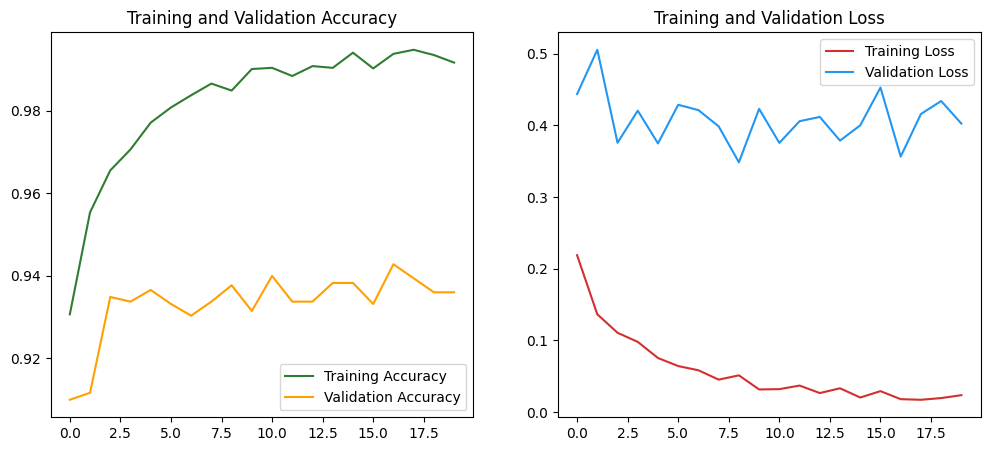

In [17]:
import matplotlib.pyplot as plt

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))
    
    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='#2e7d32')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#ffa000')
    plt.title('Training and Validation Accuracy')
    plt.legend(loc='lower right')

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', color='#d32f2f')
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='#2196f3')
    plt.title('Training and Validation Loss')
    plt.legend(loc='upper right')
    
    plt.show()

# Run this:
plot_history(history_fine)

221/221 [==============================] - 46s 202ms/step


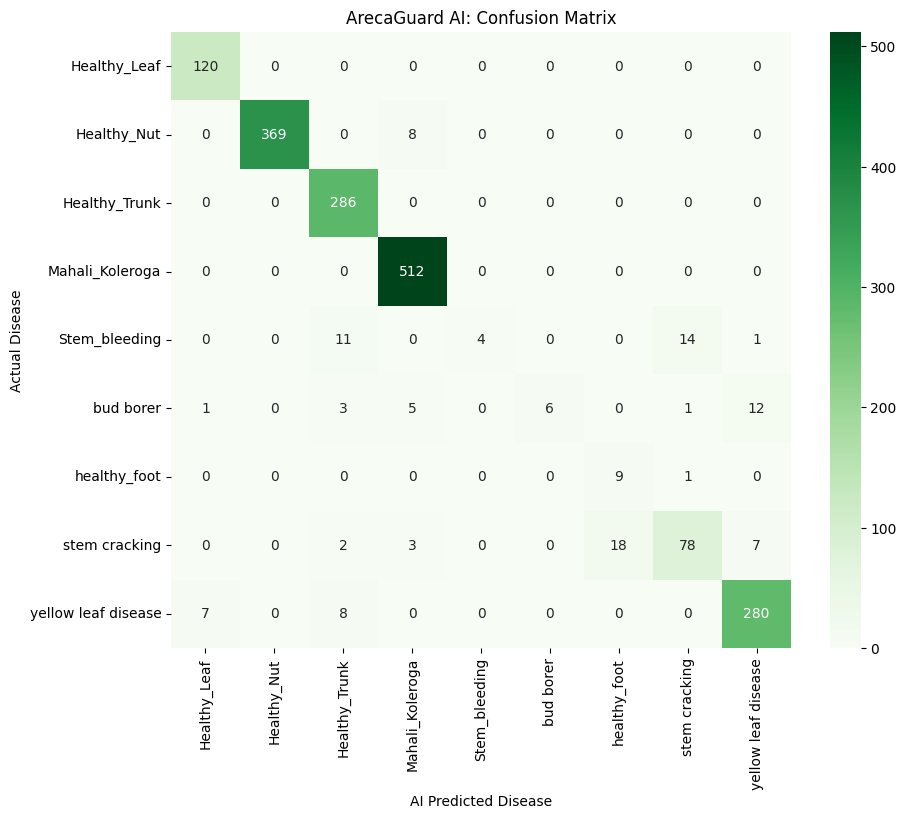

                     precision    recall  f1-score   support

       Healthy_Leaf       0.94      1.00      0.97       120
        Healthy_Nut       1.00      0.98      0.99       377
      Healthy_Trunk       0.92      1.00      0.96       286
    Mahali_Koleroga       0.97      1.00      0.98       512
      Stem_bleeding       1.00      0.13      0.24        30
          bud borer       1.00      0.21      0.35        28
       healthy_foot       0.33      0.90      0.49        10
      stem cracking       0.83      0.72      0.77       108
yellow leaf disease       0.93      0.95      0.94       295

           accuracy                           0.94      1766
          macro avg       0.88      0.77      0.74      1766
       weighted avg       0.95      0.94      0.93      1766



In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# 1. Get predictions for the entire validation set
validation_generator.reset() # Ensure we start from the beginning
Y_pred = model.predict(validation_generator)
y_pred = np.argmax(Y_pred, axis=1)

# 2. Get true labels
y_true = validation_generator.classes
class_labels = list(validation_generator.class_indices.keys())

# 3. Create Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# 4. Plot Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('ArecaGuard AI: Confusion Matrix')
plt.ylabel('Actual Disease')
plt.xlabel('AI Predicted Disease')
plt.show()

# 5. Print Detailed Report (Precision/Recall)
print(classification_report(y_true, y_pred, target_names=class_labels))

In [21]:
# Run this to see the true order for your App.py
print(train_generator.class_indices)

{'Healthy_Leaf': 0, 'Healthy_Nut': 1, 'Healthy_Trunk': 2, 'Mahali_Koleroga': 3, 'Stem_bleeding': 4, 'bud borer': 5, 'healthy_foot': 6, 'stem cracking': 7, 'yellow leaf disease': 8}


In [22]:
# Save your current stable 94% model as a backup
model.save('areca_94_PERCENT_STABLE_BASE.h5')
print("✅ Baseline model saved as 'areca_94_PERCENT_STABLE_BASE.h5'")

✅ Baseline model saved as 'areca_94_PERCENT_STABLE_BASE.h5'


In [28]:
import os
import time

# List all .h5 files in your current directory
files = [f for f in os.listdir('.') if f.endswith('.h5')]
files.sort(key=os.path.getmtime, reverse=True) # Sort by most recent

print("📂 Your Model Files (Most Recent First):")
for f in files:
    mtime = time.ctime(os.path.getmtime(f))
    size = os.path.getsize(f) // (1024 * 1024) # Size in MB
    print(f"🕒 {mtime} | 📦 {size}MB | 📄 {f}")

📂 Your Model Files (Most Recent First):
🕒 Sun Mar 22 20:39:35 2026 | 📦 282MB | 📄 areca_94_PERCENT_STABLE_BASE.h5
🕒 Sun Mar 22 19:42:32 2026 | 📦 282MB | 📄 areca_95_PERCENT_CHAMPION.h5
🕒 Sun Mar 22 18:11:28 2026 | 📦 282MB | 📄 areca_FINAL_CHAMPION.h5
🕒 Sat Mar 21 00:06:31 2026 | 📦 102MB | 📄 areca_FROZEN_BASE_85.h5
🕒 Fri Mar 20 22:10:19 2026 | 📦 102MB | 📄 areca_resnet_stage1_v2.h5


In [36]:
#The Session Peak was ~94.28%

#The Saved Model is 93.71%

In [4]:
#Code to check count of images in each folder of the Dataset
import os

# Your specific path
dataset_path = r'D:\ML Project\Areca_Disease_prediction(Resnet)\Arecanut_dataset'

print(f"{'Folder/Class':<45} | {'Image Count':<10}")
print("-" * 60)

# os.walk "digs" into all subfolders automatically
for root, dirs, files in os.walk(dataset_path):
    # Only show folders that actually contain files
    if files:
        # Get a clean name of the folder
        folder_name = os.path.relpath(root, dataset_path)
        
        # Count only image files (jpg, jpeg, png)
        count = len([f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        
        print(f"{folder_name:<45} | {count:<10}")

Folder/Class                                  | Image Count
------------------------------------------------------------
final_testing-20230830T042904Z-001\final_testing | 111       
final_testing-20230830T042904Z-001\final_testing\Healthy_Nut | 262       
final_testing-20230830T042904Z-001\final_testing\Healthy_Trunk | 199       
final_testing-20230830T042904Z-001\final_testing\Mahali_Koleroga | 356       
final_testing-20230830T042904Z-001\final_testing\stem cracking | 75        
final_testing-20230830T042904Z-001\final_testing\Stem_bleeding | 21        
final_testing-20230830T042904Z-001\final_testing\yellow leaf disease | 205       
test\bud borer                                | 36        
test\healthy_foot                             | 13        
test\Healthy_Leaf                             | 152       
test\Healthy_Nut                              | 472       
test\Healthy_Trunk                            | 359       
test\Mahali_Koleroga                          | 641       
t

In [3]:
import tensorflow as tf

# 1. Define the path to your existing .h5 model
h5_model_path = 'areca_94_PERCENT_STABLE_BASE.h5' 

# 2. Load the model and create the converter object
model = tf.keras.models.load_model(h5_model_path)
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# 3. Apply basic optimization (compression) 
# This reduces the size significantly with almost no loss in accuracy
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# 4. Perform the conversion
tflite_model = converter.convert()

# 5. Save the converted .tflite file
tflite_model_path = 'areca_model_optimized.tflite'
with open(tflite_model_path, 'wb') as f:
    f.write(tflite_model)

print(f"Success! Model converted and saved as: {tflite_model_path}")

INFO:tensorflow:Assets written to: C:\Users\Lenovo\AppData\Local\Temp\tmpeifpsl3b\assets


INFO:tensorflow:Assets written to: C:\Users\Lenovo\AppData\Local\Temp\tmpeifpsl3b\assets


Success! Model converted and saved as: areca_model_optimized.tflite
